In [1]:
from kan import *
import torch
torch.cuda.empty_cache()
import os

In [2]:
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu" )
print(device)

cuda:3


In [3]:
hust_dataset = torch.load('../Data/HUST_Data_Var2.pt')

/tmp/ipykernel_884361/3860308048.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  hust_dataset = torch.load('../Data/HUST_Data_Var2.pt')


In [4]:
train_loader = hust_dataset['train_loader']
valid_loader = hust_dataset['valid_loader']
test_loader = hust_dataset['test_loader']

In [5]:
import argparse
def get_args():
    parser = argparse.ArgumentParser('Hyper Parameters for HUST dataset')
    parser.add_argument('--model_name',type=str,default='AutoPIKAN')
    parser.add_argument('--data', type=str, default='HUST', help='XJTU, HUST, MIT, TJU')
    parser.add_argument('--batch_size', type=int, default=512, help='batch size')
    parser.add_argument('--normalization_method', type=str, default='min-max', help='min-max,z-score')

    parser.add_argument('--epochs', type=int, default=200, help='epoch')
    parser.add_argument('--early_stop', type=int, default=20, help='early stop')
    parser.add_argument('--warmup_epochs', type=int, default=30, help='warmup epoch')
    parser.add_argument('--warmup_lr', type=float, default=0.002, help='warmup lr')
    parser.add_argument('--lr', type=float, default=0.01, help='base lr')
    parser.add_argument('--final_lr', type=float, default=0.0002, help='final lr')
    parser.add_argument('--lr_F', type=float, default=0.001, help='lr of F')

    parser.add_argument('--alpha', type=float, default=1, help='loss = l_data + alpha * l_PDE + beta * l_physics')
    parser.add_argument('--beta', type=float, default=1, help='loss = l_data + alpha * l_PDE + beta * l_physics')

    parser.add_argument('--ckpt_path', type=str, default='../Notebooks/ckpt_path/autopikan_hust_var2/')
    parser.add_argument('--log_dir', type=str, default='logging.txt', help='log dir, if None, do not save')
    parser.add_argument('--save_folder', type=str, default='../Notebooks/results_of_autopikan/HUST results/autopikan_fit_1', help='save folder')
    parser.add_argument('--image_folder', type=str, default='../Images/autopikan_hust_var2/video_img_fit_1', help='save folder')
    parser.add_argument('--save_fig', type=bool, default=True, help='whether to save video image')
    parser.add_argument('--f_in_vars', type=list, default=[r'$x$', r'$t$'], help='the input variables of solution_u')
    parser.add_argument('--f_out_vars', type=list, default=[r'$u$'], help='the output variable of solution_u')
    parser.add_argument('--g_in_vars', type=list, default=[r'$u$'], help='the input variables of dynamical_F')
    parser.add_argument('--g_out_vars', type=list, default=[r'$u_t$'], help='the output variable of dynamical_F')
    parser.add_argument('--mark1', type=str, default='0.0', help='the version of autopikan-kan1')
    parser.add_argument('--mark2', type=str, default='0.0', help='the version of autopikan-kan2')
    
    args = parser.parse_args([])    # 传入空列表，避免解析 Jupyter 注入的参数
    return args
args = get_args()

In [6]:
import logging
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,mean_squared_error
def set_seed(seed):
    if seed is None:
        seed = np.random.randint(1e6)
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed) # 为了禁止hash随机化，使得实验可复现。
    torch.manual_seed(seed) # 为CPU设置随机种子
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed) # 为当前GPU设置随机种子
        torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU，为所有GPU设置随机种子
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

def get_logger(log_name='log.txt'):
    logger = logging.getLogger('mylogger')
    logger.setLevel(level=logging.DEBUG)
    formatter = logging.Formatter('%(asctime)s - function:%(funcName)s - %(levelname)s - %(message)s',datefmt='%Y-%m-%d %H:%M')

    # console = logging.StreamHandler()
    # console.setLevel(logging.INFO)
    # console.setFormatter(formatter)
    # logger.addHandler(console)

    if log_name is not None:
        handler = logging.FileHandler(log_name)
        handler.setLevel(logging.DEBUG)
        handler.setFormatter(formatter)
        logger.addHandler(handler)

    return logger

class AverageMeter(object):
    """Computes and stores the average and current value"""

    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def eval_metrix(true_label,pred_label):
    MAE = mean_absolute_error(true_label,pred_label)
    MAPE = mean_absolute_percentage_error(true_label,pred_label)
    MSE = mean_squared_error(true_label,pred_label)
    RMSE = np.sqrt(mean_squared_error(true_label,pred_label))

    return [MAE,MAPE,MSE,RMSE]

In [7]:
from torch.autograd import grad
class LR_Scheduler(object): # 用于调整优化器的学习率
    def __init__(self, optimizer, warmup_epochs, warmup_lr, num_epochs, base_lr, final_lr, iter_per_epoch=1,
                 constant_predictor_lr=False):  # 优化器、预热期的轮数、预热期的学习率、总轮数、基础学习率、最终学习率
        self.base_lr = base_lr
        self.constant_predictor_lr = constant_predictor_lr
        warmup_iter = iter_per_epoch * warmup_epochs
        warmup_lr_schedule = np.linspace(warmup_lr, base_lr, warmup_iter)   # 预热期的学习率序列，线性热身，从warmup_lr线性增加到base_lr
        decay_iter = iter_per_epoch * (num_epochs - warmup_epochs)
        cosine_lr_schedule = final_lr + 0.5 * (base_lr - final_lr) * (
                    1 + np.cos(np.pi * np.arange(decay_iter) / decay_iter)) # 衰减期的余弦学习率序列，余弦退火，从base_lr逐渐下降到final_lr，并且下降的过程是按照余弦函数的形状进行的

        self.lr_schedule = np.concatenate((warmup_lr_schedule, cosine_lr_schedule)) # 完整的学习率序列
        self.optimizer = optimizer
        self.iter = 0
        self.current_lr = 0

    def step(self): # 在每次调用时，根据当前迭代次数为优化器的参数组设置学习率
        for param_group in self.optimizer.param_groups:

            if self.constant_predictor_lr and param_group['name'] == 'predictor':   # 特殊情况，学习率保持不变
                param_group['lr'] = self.base_lr
            else:
                lr = param_group['lr'] = self.lr_schedule[self.iter]    # 学习率调整策略

        self.iter += 1
        self.current_lr = lr
        return lr

    def get_lr(self):
        return self.current_lr
    
class AutoPIKAN(nn.Module):
    def __init__(self,args):
        super(AutoPIKAN, self).__init__()
        self.args = args
        if args.save_folder is not None and not os.path.exists(args.save_folder):   # 保存传入的参数
            os.makedirs(args.save_folder)
        if args.image_folder is not None and not os.path.exists(args.image_folder):   # 保存传入的参数
            os.makedirs(args.image_folder)
            os.makedirs(args.image_folder+'/solution_u')
            os.makedirs(args.image_folder+'/dynamical_F')
        log_dir = args.log_dir if args.save_folder is None else os.path.join(args.save_folder, args.log_dir)    # 根据参数创建日志目录
        self.logger = get_logger(log_dir)   # 初始化日志记录器
        self._save_args()
        
        if args.mark1 == '0.0' and args.mark2 == '0.0':
            self.solution_u = KAN(width=[2,4,1], grid=3, k=3, seed=25, ckpt_path=args.ckpt_path + 'solution_u/',device=device)   # 求解偏微分方程解的网络
            self.dynamical_F = KAN(width=[1,2,1], grid=3, k=3, seed=25, ckpt_path=args.ckpt_path + 'dynamical_F/',device=device) # 用于计算动态方程的网络
        else:
            self.solution_u = KAN.loadckpt(args.ckpt_path + 'solution_u/'+args.mark1)   # 求解偏微分方程解的网络
            self.dynamical_F = KAN.loadckpt(args.ckpt_path + 'dynamical_F/'+args.mark2) # 用于计算动态方程的网络

        self.optimizer1 = torch.optim.Adam(self.solution_u.parameters(), lr=args.warmup_lr)
        self.optimizer2 = torch.optim.Adam(self.dynamical_F.parameters(), lr=args.lr_F)

        self.scheduler = LR_Scheduler(optimizer=self.optimizer1,
                                      warmup_epochs=args.warmup_epochs,
                                      warmup_lr=args.warmup_lr,
                                      num_epochs=args.epochs,
                                      base_lr=args.lr,
                                      final_lr=args.final_lr)

        self.loss_func = nn.MSELoss()
        self.relu = nn.ReLU()

        # 模型的最好参数(the best model)
        self.best_model = None

        # loss = loss1 + alpha*loss2 + beta*loss3
        self.alpha = self.args.alpha
        self.beta = self.args.beta

    def _save_args(self):
        if self.args.log_dir is not None:
            # 中文： 把parser中的参数保存在self.logger中
            # English: save the parameters in parser to self.logger
            self.logger.info("Args:")
            for k, v in self.args.__dict__.items():
                self.logger.critical(f"\t{k}:{v}")

    def clear_logger(self):
        self.logger.removeHandler(self.logger.handlers[0])
        self.logger.handlers.clear()

    def predict(self,xt):
        return self.solution_u(xt)

    def Test(self,testloader):  # 在测试数据集上进行测试，返回真实标签和预测标签
        self.eval()
        true_label = []
        pred_label = []
        with torch.no_grad():
            for iter,(x1,_,y1,_) in enumerate(testloader):
                x1 = x1.to(device)
                u1 = self.predict(x1)
                true_label.append(y1.cpu().detach().numpy())
                pred_label.append(u1.cpu().detach().numpy())
        pred_label = np.concatenate(pred_label,axis=0)
        true_label = np.concatenate(true_label,axis=0)

        return true_label,pred_label

    def Valid(self,validloader):    # 在验证数据集上进行验证，返回均方误差
        self.eval()
        true_label = []
        pred_label = []
        with torch.no_grad():
            for iter,(x1,_,y1,_) in enumerate(validloader):
                x1 = x1.to(device)
                u1 = self.predict(x1)
                true_label.append(y1.cpu().detach().numpy())
                pred_label.append(u1.cpu().detach().numpy())
        pred_label = np.concatenate(pred_label,axis=0)
        true_label = np.concatenate(true_label,axis=0)
        mse = self.loss_func(torch.tensor(pred_label),torch.tensor(true_label))
        return mse.item()

    def forward(self,xt):   # 执行前向传播，计算偏微分方程的解和动态方程的值
        xt.requires_grad = True
        x = xt[:,0:-1]
        t = xt[:,-1:]

        u = self.solution_u(torch.cat((x,t),dim=1))

        u_t = grad(u.sum(),t,   
                   create_graph=True,   
                   only_inputs=True,    
                   allow_unused=True)[0]  
                                          
        # u_x = grad(u.sum(),x,
        #            create_graph=True,
        #            only_inputs=True,
        #            allow_unused=True)[0]

        F = self.dynamical_F(u)

        f = u_t - F
        return u,f

    def train_one_epoch(self,epoch,dataloader):
        self.train()
        loss1_meter = AverageMeter()    # 记录损失的总和以及计算的次数，方便后续求平均损失
        loss2_meter = AverageMeter()
        loss3_meter = AverageMeter()
        for iter,(x1,x2,y1,y2) in enumerate(dataloader):
            x1,x2,y1,y2 = x1.to(device),x2.to(device),y1.to(device),y2.to(device)
            u1,f1 = self.forward(x1)
            u2,f2 = self.forward(x2)

            # data loss
            loss1 = 0.5*self.loss_func(u1,y1) + 0.5*self.loss_func(u2,y2)

            # PDE loss
            f_target = torch.zeros_like(f1)
            loss2 = 0.5*self.loss_func(f1,f_target) + 0.5*self.loss_func(f2,f_target)

            # physics loss  u2-u1<0, considering capacity regeneration
            loss3 = self.relu(torch.mul(u2-u1,y1-y2)).sum() # 确保真实值和预测值的单调性是一致的

            # total loss
            loss = loss1 + self.alpha*loss2 + self.beta*loss3

            self.optimizer1.zero_grad()
            self.optimizer2.zero_grad()
            loss.backward()
            self.optimizer1.step()
            self.optimizer2.step()

            loss1_meter.update(loss1.item())
            loss2_meter.update(loss2.item())
            loss3_meter.update(loss3.item())

            if (iter+1) % 50 == 0:
                info = "[epoch:{} iter:{}] data loss:{:.6f}, PDE loss:{:.6f}, physics loss:{:.6f}".format(epoch,iter+1,loss1,loss2,loss3)
                self.logger.info(info)
        return loss1_meter.avg,loss2_meter.avg,loss3_meter.avg

    def Train(self,trainloader,validloader=None,testloader=None):
        min_valid_mse = 10
        valid_mse = 10
        early_stop = 0
        best_fit_first = True
        for e in range(1,self.args.epochs+1):
            early_stop += 1
            loss1,loss2,loss3 = self.train_one_epoch(e,trainloader)
            current_lr = self.scheduler.step()
            info = '[Train] epoch:{}, lr:{:.6f}, ' \
                   'total loss:{:.6f}'.format(e,current_lr,loss1+self.alpha*loss2+self.beta*loss3)
            self.logger.info(info)
            if e % 1 == 0 and validloader is not None:
                valid_mse = self.Valid(validloader)
                info = '[Valid] epoch:{}, MSE: {}'.format(e,valid_mse)
                self.logger.info(info)
            if valid_mse < min_valid_mse and testloader is not None:
                min_valid_mse = valid_mse
                true_label,pred_label = self.Test(testloader)
                [MAE, MAPE, MSE, RMSE] = eval_metrix(pred_label, true_label)
                info = '[Test] MSE: {:.8f}, MAE: {:.6f}, MAPE: {:.6f}, RMSE: {:.6f}'.format(MSE, MAE, MAPE, RMSE)
                self.logger.info(info)
                early_stop = 0

                ############################### save ############################################
                self.best_model = {'solution_u':self.solution_u.state_dict(),
                                   'dynamical_F':self.dynamical_F.state_dict()}
                if best_fit_first:
                    self.solution_u.log_history('best_fit')
                    self.dynamical_F.log_history('best_fit')
                    round1 = self.solution_u.round
                    state_id1 = self.solution_u.state_id
                    round2 = self.dynamical_F.round
                    state_id2 = self.dynamical_F.state_id
                    best_fit_first = False
                else:
                    self.solution_u.saveckpt(args.ckpt_path + 'solution_u/'+str(round1)+'.'+str(state_id1))
                    self.dynamical_F.saveckpt(args.ckpt_path + 'dynamical_F/'+str(round2)+'.'+str(state_id2))
                if self.args.save_folder is not None:
                    np.save(os.path.join(self.args.save_folder, 'true_label.npy'), true_label)
                    np.save(os.path.join(self.args.save_folder, 'pred_label.npy'), pred_label)
                
            if args.save_fig:
                self.solution_u.plot(folder=args.image_folder+'/solution_u', in_vars=args.f_in_vars, out_vars=args.f_out_vars, title="F(·) Step {}".format(e))
                plt.savefig(args.image_folder + '/solution_u/' + str(e) + '.jpg', bbox_inches='tight', dpi=200)
                plt.close()
                self.dynamical_F.plot(folder=args.image_folder+'/dynamical_F', in_vars=args.g_in_vars, out_vars=args.g_out_vars, title="G(·) Step {}".format(e))
                plt.savefig(args.image_folder + '/dynamical_F/' + str(e) + '.jpg', bbox_inches='tight', dpi=200)
                plt.close()

                ##################################################################################
            if self.args.early_stop is not None and early_stop > self.args.early_stop:
                info = 'early stop at epoch {}'.format(e)
                self.logger.info(info)
                break
        self.clear_logger()
        if self.args.save_folder is not None:
            torch.save(self.best_model,os.path.join(self.args.save_folder,'model.pth'))
            self.solution_u.log_history('fit')
            self.dynamical_F.log_history('fit')


In [8]:
set_seed(25)       
autopikan = AutoPIKAN(args)
autopikan.Train(trainloader=train_loader,validloader=valid_loader,testloader=test_loader)

checkpoint directory created: ../Notebooks/ckpt_path/autopikan_hust_var2/solution_u/
saving model version 0.0
checkpoint directory created: ../Notebooks/ckpt_path/autopikan_hust_var2/dynamical_F/
saving model version 0.0
saving model version 0.1
saving model version 0.1
saving model version 0.2
saving model version 0.2


In [26]:
args.mark1 = args.mark2 = '0.2'
autopikan = AutoPIKAN(args)
true_label, pred_label = autopikan.Test(testloader=test_loader)
metrics = eval_metrix(pred_label, true_label)
print(f"Metrics for AutoPIKAN forecast: MAE:{metrics[0]}, MAPE:{metrics[1]}, MSE:{metrics[2]}, RMSE:{metrics[3]}")

Metrics for AutoPIKAN forecast: MAE:0.008867637254297733, MAPE:0.008956627920269966, MSE:0.00011034192721126601, RMSE:0.010504376143217087


In [14]:
import os
import numpy as np
from PIL import Image  # 用于图片拼接
import moviepy.video.io.ImageSequenceClip

video_name='autopikan_hust_var2'
fps=10

for name in ['solution_u','dynamical_F']:
    all_image_files = []
    image_folder = args.image_folder + '/' + name
    files = os.listdir(image_folder)
    train_index = []
    for file in files:
        if file[0].isdigit() and file.endswith('.jpg'):
            train_index.append(int(file[:-4]))
    train_index = np.sort(train_index)
    image_files = [image_folder+'/'+str(index)+'.jpg' for index in train_index]
    all_image_files += image_files
    all_image_files.append(all_image_files[-1])
    clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(all_image_files, fps=fps)
    output_path = "../Videos/"+video_name+'/video_fit_1/'+name+".mp4"
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    clip.write_videofile(output_path)

image_folder_solution = os.path.join(args.image_folder, 'solution_u')  # solution_u 文件夹路径
image_folder_dynamical = os.path.join(args.image_folder, 'dynamical_F')  # dynamical_F 文件夹路径

# 步骤1：获取两个文件夹中共同的图片索引（确保名称一致）
def get_common_indices(folder1, folder2):
    # 获取 folder1 中所有数字命名的 jpg 图片索引
    indices1 = []
    for file in os.listdir(folder1):
        if file[0].isdigit() and file.endswith('.jpg'):
            indices1.append(int(file[:-4]))
    # 获取 folder2 中所有数字命名的 jpg 图片索引
    indices2 = []
    for file in os.listdir(folder2):
        if file[0].isdigit() and file.endswith('.jpg'):
            indices2.append(int(file[:-4]))
    # 取交集并排序（确保顺序一致）
    common_indices = sorted(list(set(indices1) & set(indices2)))
    return common_indices

common_indices = get_common_indices(image_folder_solution, image_folder_dynamical)

# 步骤2：拼接同名图片（横向并列）
merged_images = []
for idx in common_indices:
    # 读取 solution_u 的图片
    img_solution_path = os.path.join(image_folder_solution, f"{idx}.jpg")
    img_solution = Image.open(img_solution_path)
    # 读取 dynamical_F 的图片
    img_dynamical_path = os.path.join(image_folder_dynamical, f"{idx}.jpg")
    img_dynamical = Image.open(img_dynamical_path)
    
    # 确保两张图片尺寸一致（不一致时可resize）
    if img_solution.size != img_dynamical.size:
        # 示例：将 dynamical_F 图片 resize 为 solution_u 的尺寸（根据需求调整）
        img_dynamical = img_dynamical.resize(img_solution.size)
    
    # 横向拼接（左右并列）
    merged_img = Image.new('RGB', (img_solution.width + img_dynamical.width, img_solution.height))
    merged_img.paste(img_solution, (0, 0))
    merged_img.paste(img_dynamical, (img_solution.width, 0))
    
    # 纵向拼接（上下并列，可选）
    # merged_img = Image.new('RGB', (img_solution.width, img_solution.height + img_dynamical.height))
    # merged_img.paste(img_solution, (0, 0))
    # merged_img.paste(img_dynamical, (0, img_solution.height))
    
    # 保存拼接后的图片到内存（或临时路径）
    merged_images.append(merged_img)
merged_images.append(merged_images[-1])

# 步骤3：生成合并后的视频（需要将 PIL.Image 对象转为文件路径或数组）
# 注意：moviepy 的 ImageSequenceClip 需要图片路径或 numpy 数组，这里转为数组
merged_frames = [np.array(img) for img in merged_images]

# 生成视频
clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(merged_frames, fps=fps)
output_path = os.path.join("../Videos/", video_name, 'video_fit_1', 'merged_video.mp4')
os.makedirs(os.path.dirname(output_path), exist_ok=True)  # 确保输出目录存在
clip.write_videofile(output_path)

MoviePy - Building video ../Videos/autopikan_hust_var2/video_fit_1/solution_u.mp4.
MoviePy - Writing video ../Videos/autopikan_hust_var2/video_fit_1/solution_u.mp4



MoviePy - Done !
MoviePy - video ready ../Videos/autopikan_hust_var2/video_fit_1/solution_u.mp4
MoviePy - Building video ../Videos/autopikan_hust_var2/video_fit_1/dynamical_F.mp4.
MoviePy - Writing video ../Videos/autopikan_hust_var2/video_fit_1/dynamical_F.mp4



MoviePy - Done !
MoviePy - video ready ../Videos/autopikan_hust_var2/video_fit_1/dynamical_F.mp4
MoviePy - Building video ../Videos/autopikan_hust_var2/video_fit_1/merged_video.mp4.
MoviePy - Writing video ../Videos/autopikan_hust_var2/video_fit_1/merged_video.mp4



MoviePy - Done !
MoviePy - video ready ../Videos/autopikan_hust_var2/video_fit_1/merged_video.mp4


/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

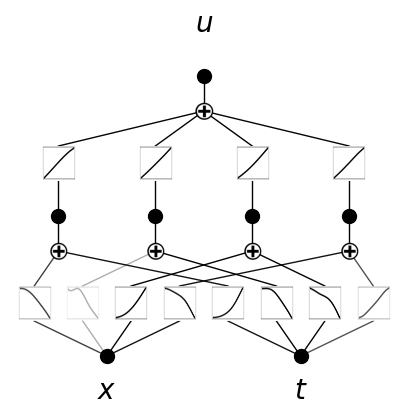

In [27]:
autopikan.solution_u = KAN.loadckpt('../Notebooks/ckpt_path/autopikan_hust_var2/solution_u/0.2')
autopikan.solution_u.plot(folder="../Images/autopikan_hust_var2/paper_img/kan1_fit_1/full_png", in_vars=[r'$x$', r'$t$'], out_vars=[r'$u$'])

saving model version 1.3


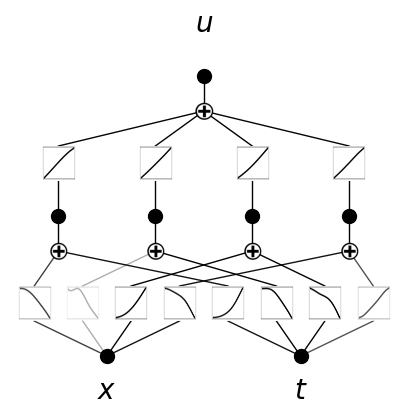

In [28]:
autopikan.solution_u = autopikan.solution_u.prune()
autopikan.solution_u.plot(folder="../Images/autopikan_hust_var2/paper_img/kan1_prune_1/full_png", in_vars=[r'$x$', r'$t$'], out_vars=[r'$u$'])

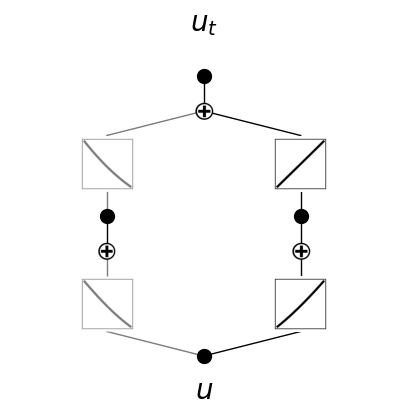

In [29]:
autopikan.dynamical_F = KAN.loadckpt('../Notebooks/ckpt_path/autopikan_hust_var2/dynamical_F/0.2')
autopikan.dynamical_F.plot(folder="../Images/autopikan_hust_var2/paper_img/kan2_fit_1/full_png", in_vars=[r'$u$'], out_vars=[r'$u_t$'])

saving model version 1.3


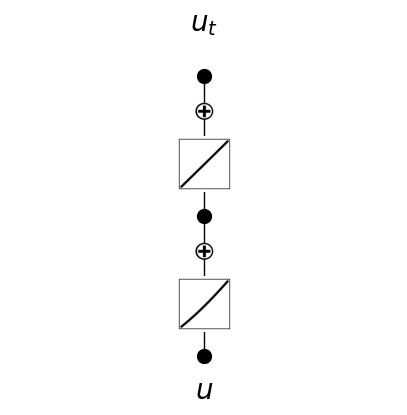

In [30]:
autopikan.dynamical_F = autopikan.dynamical_F.prune(node_th=0.25,edge_th=0.5)
autopikan.dynamical_F.plot(folder="../Images/autopikan_hust_var2/paper_img/kan2_prune_1/full_png", in_vars=[r'$u$'], out_vars=[r'$u_t$'])

In [31]:
args.mark1 = args.mark2 = '1.3'
autopikan = AutoPIKAN(args)
true_label, pred_label = autopikan.Test(testloader=test_loader)
metrics = eval_metrix(pred_label, true_label)
print(f"Metrics for AutoPIKAN forecast: MAE:{metrics[0]}, MAPE:{metrics[1]}, MSE:{metrics[2]}, RMSE:{metrics[3]}")

/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

Metrics for AutoPIKAN forecast: MAE:0.008867637254297733, MAPE:0.008956627920269966, MSE:0.00011034192721126601, RMSE:0.010504376143217087


In [32]:
args.mark1 = args.mark2 = '1.3'
args.epochs = 100
args.save_folder = '../Notebooks/results_of_autopikan/HUST results/autopikan_fit_2'
args.image_folder = '../Images/autopikan_hust_var2/video_img_fit_2'
autopikan = AutoPIKAN(args)
autopikan.Train(trainloader=train_loader,validloader=valid_loader,testloader=test_loader)

/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

saving model version 2.4
saving model version 2.4
saving model version 2.5
saving model version 2.5


In [35]:
args.mark1 = args.mark2 = '2.5'
autopikan = AutoPIKAN(args)
true_label, pred_label = autopikan.Test(testloader=test_loader)
metrics = eval_metrix(pred_label, true_label)
print(f"Metrics for AutoPIKAN forecast: MAE:{metrics[0]}, MAPE:{metrics[1]}, MSE:{metrics[2]}, RMSE:{metrics[3]}")

/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

Metrics for AutoPIKAN forecast: MAE:0.008653898723423481, MAPE:0.00876794196665287, MSE:0.0001073856110451743, RMSE:0.010362702421844006


In [36]:
video_name='autopikan_hust_var2'
fps=10

for name in ['solution_u','dynamical_F']:
    all_image_files = []
    image_folder = args.image_folder + '/' + name
    files = os.listdir(image_folder)
    train_index = []
    for file in files:
        if file[0].isdigit() and file.endswith('.jpg'):
            train_index.append(int(file[:-4]))
    train_index = np.sort(train_index)
    image_files = [image_folder+'/'+str(index)+'.jpg' for index in train_index]
    all_image_files += image_files
    all_image_files.append(all_image_files[-1])
    clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(all_image_files, fps=fps)
    output_path = "../Videos/"+video_name+'/video_fit_2/'+name+".mp4"
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    clip.write_videofile(output_path)

image_folder_solution = os.path.join(args.image_folder, 'solution_u')  # solution_u 文件夹路径
image_folder_dynamical = os.path.join(args.image_folder, 'dynamical_F')  # dynamical_F 文件夹路径

# 步骤1：获取两个文件夹中共同的图片索引（确保名称一致）
def get_common_indices(folder1, folder2):
    # 获取 folder1 中所有数字命名的 jpg 图片索引
    indices1 = []
    for file in os.listdir(folder1):
        if file[0].isdigit() and file.endswith('.jpg'):
            indices1.append(int(file[:-4]))
    # 获取 folder2 中所有数字命名的 jpg 图片索引
    indices2 = []
    for file in os.listdir(folder2):
        if file[0].isdigit() and file.endswith('.jpg'):
            indices2.append(int(file[:-4]))
    # 取交集并排序（确保顺序一致）
    common_indices = sorted(list(set(indices1) & set(indices2)))
    return common_indices

common_indices = get_common_indices(image_folder_solution, image_folder_dynamical)

# 步骤2：拼接同名图片（横向并列）
merged_images = []
for idx in common_indices:
    # 读取 solution_u 的图片
    img_solution_path = os.path.join(image_folder_solution, f"{idx}.jpg")
    img_solution = Image.open(img_solution_path)
    # 读取 dynamical_F 的图片
    img_dynamical_path = os.path.join(image_folder_dynamical, f"{idx}.jpg")
    img_dynamical = Image.open(img_dynamical_path)
    
    # 确保两张图片尺寸一致（不一致时可resize）
    if img_solution.size != img_dynamical.size:
        # 示例：将 dynamical_F 图片 resize 为 solution_u 的尺寸（根据需求调整）
        img_dynamical = img_dynamical.resize(img_solution.size)
    
    # 横向拼接（左右并列）
    merged_img = Image.new('RGB', (img_solution.width + img_dynamical.width, img_solution.height))
    merged_img.paste(img_solution, (0, 0))
    merged_img.paste(img_dynamical, (img_solution.width, 0))
    
    # 纵向拼接（上下并列，可选）
    # merged_img = Image.new('RGB', (img_solution.width, img_solution.height + img_dynamical.height))
    # merged_img.paste(img_solution, (0, 0))
    # merged_img.paste(img_dynamical, (0, img_solution.height))
    
    # 保存拼接后的图片到内存（或临时路径）
    merged_images.append(merged_img)
merged_images.append(merged_images[-1])

# 步骤3：生成合并后的视频（需要将 PIL.Image 对象转为文件路径或数组）
# 注意：moviepy 的 ImageSequenceClip 需要图片路径或 numpy 数组，这里转为数组
merged_frames = [np.array(img) for img in merged_images]

# 生成视频
clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(merged_frames, fps=fps)
output_path = os.path.join("../Videos/", video_name, 'video_fit_2', 'merged_video.mp4')
os.makedirs(os.path.dirname(output_path), exist_ok=True)  # 确保输出目录存在
clip.write_videofile(output_path)

MoviePy - Building video ../Videos/autopikan_hust_var2/video_fit_2/solution_u.mp4.
MoviePy - Writing video ../Videos/autopikan_hust_var2/video_fit_2/solution_u.mp4



MoviePy - Done !
MoviePy - video ready ../Videos/autopikan_hust_var2/video_fit_2/solution_u.mp4
MoviePy - Building video ../Videos/autopikan_hust_var2/video_fit_2/dynamical_F.mp4.
MoviePy - Writing video ../Videos/autopikan_hust_var2/video_fit_2/dynamical_F.mp4



MoviePy - Done !
MoviePy - video ready ../Videos/autopikan_hust_var2/video_fit_2/dynamical_F.mp4
MoviePy - Building video ../Videos/autopikan_hust_var2/video_fit_2/merged_video.mp4.
MoviePy - Writing video ../Videos/autopikan_hust_var2/video_fit_2/merged_video.mp4



MoviePy - Done !
MoviePy - video ready ../Videos/autopikan_hust_var2/video_fit_2/merged_video.mp4


/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

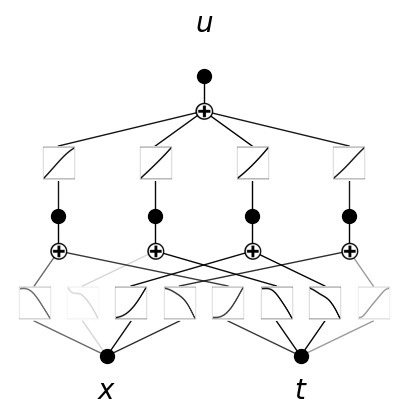

In [37]:
autopikan.solution_u = KAN.loadckpt('../Notebooks/ckpt_path/autopikan_hust_var2/solution_u/2.5')
autopikan.solution_u.plot(folder="../Images/autopikan_hust_var2/paper_img/kan1_fit_2/full_png", in_vars=[r'$x$', r'$t$'], out_vars=[r'$u$'])

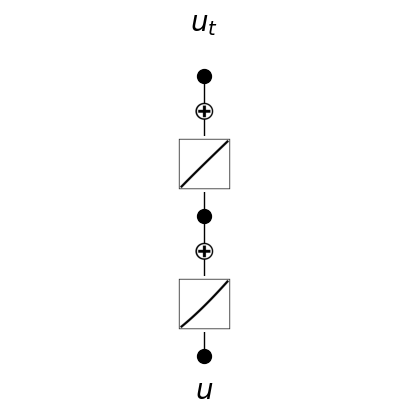

In [38]:
autopikan.dynamical_F = KAN.loadckpt('../Notebooks/ckpt_path/autopikan_hust_var2/dynamical_F/2.5')
autopikan.dynamical_F.plot(folder="../Images/autopikan_hust_var2/paper_img/kan2_fit_2/full_png", in_vars=[r'$u$'], out_vars=[r'$u_t$'])

In [39]:
add_symbolic('torch.special.bessel_j0',torch.special.bessel_j0)
add_symbolic('torch.special.erf',torch.special.erf)
add_symbolic('torch.special.sinc',torch.special.sinc)
add_symbolic('torch.special.softmax',lambda x: torch.special.softmax(x, dim=0))
add_symbolic('torch.sigmoid', torch.sigmoid)
add_symbolic('torch.relu',torch.relu)
add_symbolic('torch.cosh',torch.cosh)
add_symbolic('torch.sinh',torch.sinh)
add_symbolic('torch.arcsinh',torch.arcsinh)
add_symbolic('torch.arccosh',torch.arccosh)

In [40]:
autopikan.solution_u.auto_symbolic()

fixing (0,0,0) with torch.special.sinc, r2=0.9998399615287781, c=1
fixing (0,0,1) with torch.arcsinh, r2=0.9913197159767151, c=1
fixing (0,0,2) with torch.special.erf, r2=0.9999694228172302, c=1
fixing (0,0,3) with torch.arcsinh, r2=0.9998373985290527, c=1
fixing (0,1,0) with torch.special.bessel_j0, r2=0.9998176097869873, c=1
fixing (0,1,1) with torch.special.bessel_j0, r2=0.9997240900993347, c=1
fixing (0,1,2) with torch.sinh, r2=0.9994699358940125, c=1
fixing (0,1,3) with torch.special.bessel_j0, r2=0.9991585612297058, c=1
fixing (1,0,0) with torch.arcsinh, r2=0.9998800158500671, c=1
fixing (1,1,0) with torch.sinh, r2=0.9999854564666748, c=1
fixing (1,2,0) with torch.cosh, r2=0.9999839067459106, c=1
fixing (1,3,0) with torch.arcsinh, r2=0.9998704195022583, c=1
saving model version 3.6


In [42]:
print(autopikan.dynamical_F.suggest_symbolic(0,0,0,topk=30))
print(autopikan.dynamical_F.suggest_symbolic(1,0,0,topk=30))

                   function  fitting r2    r2 loss  complexity  \
0             torch.arcsinh    0.999992 -15.748413           1   
1                torch.sinh    0.999990 -15.583109           1   
2                torch.cosh    0.999989 -15.537407           1   
3         torch.special.erf    0.999979 -14.997826           1   
4   torch.special.bessel_j0    0.999971 -14.649564           1   
5        torch.special.sinc    0.999964 -14.419229           1   
6             torch.arccosh    0.999930 -13.602569           1   
7             torch.sigmoid    0.999927 -13.557293           1   
8                       x^2    0.999995 -16.006936           2   
9                       exp    0.999990 -15.583109           2   
10                      sin    0.999983 -15.171000           2   
11                      cos    0.999983 -15.171000           2   
12                    1/x^2    0.999983 -15.164669           2   
13                      1/x    0.999972 -14.674083           2   
14        

In [43]:
autopikan.dynamical_F.fix_symbolic(0,0,0,'x^2')
autopikan.dynamical_F.fix_symbolic(1,0,0,'x')

r2 is 0.9999948143959045
saving model version 3.6
Best value at boundary.
r2 is 0.9999312162399292
saving model version 3.7


tensor(0.9999, device='cuda:3')

In [44]:
args.mark1 = '3.6'
args.mark2 = '3.7'
autopikan = AutoPIKAN(args)
true_label, pred_label = autopikan.Test(testloader=test_loader)
metrics = eval_metrix(pred_label, true_label)
print(f"Metrics for AutoPIKAN forecast: MAE:{metrics[0]}, MAPE:{metrics[1]}, MSE:{metrics[2]}, RMSE:{metrics[3]}")

/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

Metrics for AutoPIKAN forecast: MAE:0.008834943175315857, MAPE:0.008935410529375076, MSE:0.00011441151582403108, RMSE:0.010696331970393658


/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

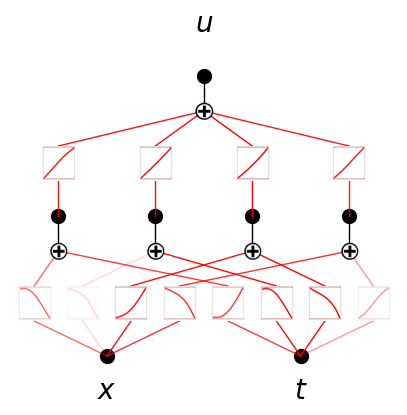

In [45]:
autopikan.solution_u = KAN.loadckpt('../Notebooks/ckpt_path/autopikan_hust_var2/solution_u/3.6')
autopikan.solution_u.plot(folder="../Images/autopikan_hust_var2/paper_img/kan1_symbolic_1/full_png", in_vars=[r'$x$', r'$t$'], out_vars=[r'$u$'])

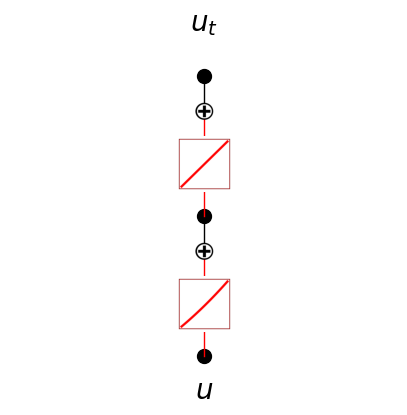

In [46]:
autopikan.dynamical_F = KAN.loadckpt('../Notebooks/ckpt_path/autopikan_hust_var2/dynamical_F/3.7')
autopikan.dynamical_F.plot(folder="../Images/autopikan_hust_var2/paper_img/kan2_symbolic_1/full_png", in_vars=[r'$u$'], out_vars=[r'$u_t$'])

In [47]:
formula1, variables1 = autopikan.solution_u.symbolic_formula(var=[r'x', r't'])
print(formula1[0])
print(ex_round(formula1[0],4))

-0.104321405291557*torch.arcsinh(-0.412444294600618*torch.arcsinh(2.02327990531921 - 3.3887996673584*x) - 0.278360072647359*torch.special.bessel_j0(1.80079984664917 - 1.4236798286438*t) + 0.61887466145572) - 0.0847505927085876*torch.arcsinh(-1.99107963647253*torch.special.bessel_j0(3.07112002372742 - 0.992239892482758*t) + 0.869745821113611*torch.special.sinc(0.927679836750031 - 0.644479870796204*x) - 0.787580264244212) + 8.25579045340419e-5*torch.cosh(-0.046194356036974*torch.sinh(-1.43815982341766*t - 0.801199853420258) + 0.168166680585827*torch.special.erf(0.580479860305786 - 0.887919902801514*x) - 10.2407113411525) - 0.00309343566186726*torch.sinh(-0.00511838204221232*torch.arcsinh(2.10799980163574 - 4.60148000717163*x) + 0.224774814921677*torch.special.bessel_j0(2.83471989631653 - 1.35583984851837*t) - 6.28041031020066) - 0.892094075679779
-0.1043*torch.arcsinh(-0.4124*torch.arcsinh(2.0233 - 3.3888*x) - 0.2784*torch.special.bessel_j0(1.8008 - 1.4237*t) + 0.6189) - 0.0848*torch.arc

In [48]:
formula2, variables2 = autopikan.dynamical_F.symbolic_formula(var=[r'u'])
print(formula2[0])
print(ex_round(formula2[0],4))

0.528928825968328*(0.0145992613719317 - u)**2 - 0.642222557439704
0.5289*(0.0146 - u)**2 - 0.6422


可以计算dynamical_F对应Verhulst模型的参数：

$$
\frac{\partial u}{\partial t} = r(u-C)(1-\frac{u-C}{K-C})
$$

$$
\frac{\partial u}{\partial t} = a(bu+d)^2+e
$$

推导该方程组，可得：

$$
r = -\sqrt{-4ab^2e} 
$$

$$
C = -\frac{2(ad^2+e)}{r+2abd} = - \frac{2be+dr}{br} 
$$

$$
K = -\frac{r}{ab^2} + C
$$

代入具体数值，可得r，C，K。

In [49]:
import numpy as np

# 给定参数值
a = 0.528928825968328  # 请根据实际情况修改
b = 1 # 请根据实际情况修改
d = - 0.0145992613719317  # 请根据实际情况修改
e = - 0.642222557439704  # 请根据实际情况修改

# 计算 r
try:
    sqrt_value = -4 * a * (b ** 2) * e
    if sqrt_value < 0:
        print("警告: 根号内的值为负数，将计算复数结果")
    r = -np.sqrt(sqrt_value)
except ValueError as ve:
    print(f"错误: 无法计算平方根: {ve}")
    exit(1)

# 计算 C（两种方法）
try:
    # 第一种方法
    denominator1 = r + 2 * a * b * d
    if denominator1 == 0:
        print("错误: 第一个分母为零，无法计算 C")
        exit(1)
    C1 = -2 * (a * (d ** 2) + e) / denominator1
    
    # 第二种方法
    numerator2 = 2 * b * e + d * r
    denominator2 = b * r
    if denominator2 == 0:
        print("错误: 第二个分母为零，无法计算 C")
        exit(1)
    C2 = -numerator2 / denominator2
    
    # 验证两种方法结果是否一致（考虑浮点数误差）
    if np.isclose(C1, C2, atol=1e-8):
        C = C1
    else:
        print(f"警告: 两种方法计算的 C 值不一致: C1={C1}, C2={C2}")
        C = C1  # 默认使用第一种方法的结果
except Exception as e:
    print(f"错误: 计算 C 时出错: {e}")
    exit(1)

# 计算 K
try:
    denominator_K = a * (b ** 2)
    if denominator_K == 0:
        print("错误: 分母为零，无法计算 K")
        exit(1)
    K = -r / denominator_K + C
except Exception as e:
    print(f"错误: 计算 K 时出错: {e}")
    exit(1)

# 输出结果
print(f"计算结果:")
print(f"r = {r:.6f}")
print(f"C = {C:.6f}")
print(f"K = {K:.6f}")

计算结果:
r = -1.165659
C = -1.087306
K = 1.116504


In [50]:
def complex_expression_kan1_1(input):
    # Unpack inputs
    x, t = input

    # First part of the expression
    Eq = -0.104321405291557*torch.arcsinh(-0.412444294600618*torch.arcsinh(2.02327990531921 - 3.3887996673584*x) - 0.278360072647359*torch.special.bessel_j0(1.80079984664917 - 1.4236798286438*t) + 0.61887466145572) - 0.0847505927085876*torch.arcsinh(-1.99107963647253*torch.special.bessel_j0(3.07112002372742 - 0.992239892482758*t) + 0.869745821113611*torch.special.sinc(0.927679836750031 - 0.644479870796204*x) - 0.787580264244212) + 8.25579045340419e-5*torch.cosh(-0.046194356036974*torch.sinh(-1.43815982341766*t - 0.801199853420258) + 0.168166680585827*torch.special.erf(0.580479860305786 - 0.887919902801514*x) - 10.2407113411525) - 0.00309343566186726*torch.sinh(-0.00511838204221232*torch.arcsinh(2.10799980163574 - 4.60148000717163*x) + 0.224774814921677*torch.special.bessel_j0(2.83471989631653 - 1.35583984851837*t) - 6.28041031020066) - 0.892094075679779
    
    # Return the result as a tensor
    return torch.tensor([Eq])

In [51]:
def complex_expression_kan1(input):
    # Unpack inputs
    x, t = input

    # First part of the expression
    Eq = -0.1043*torch.arcsinh(-0.4124*torch.arcsinh(2.0233 - 3.3888*x) - 0.2784*torch.special.bessel_j0(1.8008 - 1.4237*t) + 0.6189) - 0.0848*torch.arcsinh(-1.9911*torch.special.bessel_j0(3.0711 - 0.9922*t) + 0.8697*torch.special.sinc(0.9277 - 0.6445*x) - 0.7876) + 0.0001*torch.cosh(-0.0462*torch.sinh(-1.4382*t - 0.8012) + 0.1682*torch.special.erf(0.5805 - 0.8879*x) - 10.2407) - 0.0031*torch.sinh(-0.0051*torch.arcsinh(2.108 - 4.6015*x) + 0.2248*torch.special.bessel_j0(2.8347 - 1.3558*t) - 6.2804) - 0.8921
   
    # Return the result as a tensor
    return torch.tensor([Eq])

In [52]:
args.mark1 = args.mark2 = '2.5'
autopikan = AutoPIKAN(args)
true_label, pred_label = autopikan.Test(testloader=test_loader)

symbolic_forecast = []
symbolic_forecast1 = []
with torch.no_grad():
    for iter,(x1,_,y1,_) in enumerate(test_loader):
        for i in range(x1.shape[0]):
            input = x1[i]
            symbolic_result = complex_expression_kan1(input) 
            symbolic_forecast.append(symbolic_result.cpu().numpy())  
            symbolic_result1 = complex_expression_kan1_1(input)  
            symbolic_forecast1.append(symbolic_result1.cpu().numpy())  

symbolic_forecast = np.array(symbolic_forecast)
symbolic_forecast1 = np.array(symbolic_forecast1)

autopikan_metrics = eval_metrix(true_label, pred_label)
symbolic_metrics = eval_metrix(true_label, symbolic_forecast)
symbolic_metrics1 = eval_metrix(true_label, symbolic_forecast1)

print(f"Metrics for AutoPIKAN forecast: MAE:{autopikan_metrics[0]}, MAPE:{autopikan_metrics[1]}, MSE:{autopikan_metrics[2]}, RMSE:{autopikan_metrics[3]}")
print(f"Metrics for Symbolic forecast: MAE:{symbolic_metrics[0]}, MAPE:{symbolic_metrics[1]}, MSE:{symbolic_metrics[2]}, RMSE:{symbolic_metrics[3]}")
print(f"Metrics for Symbolic forecast 1: MAE:{symbolic_metrics1[0]}, MAPE:{symbolic_metrics1[1]}, MSE:{symbolic_metrics1[2]}, RMSE:{symbolic_metrics1[3]}")

Metrics for AutoPIKAN forecast: MAE:0.008653898723423481, MAPE:0.008752102963626385, MSE:0.0001073856110451743, RMSE:0.010362702421844006
Metrics for Symbolic forecast: MAE:0.21206440031528473, MAPE:0.21519000828266144, MSE:0.045798514038324356, RMSE:0.21400587260723114
Metrics for Symbolic forecast 1: MAE:0.008834930136799812, MAPE:0.008928732015192509, MSE:0.00011441136302892119, RMSE:0.01069632451981306


image saved at ../Images/autopikan_hust_var2/paper_img/reality_vs_autopikan_vs_symbolic_first400.png


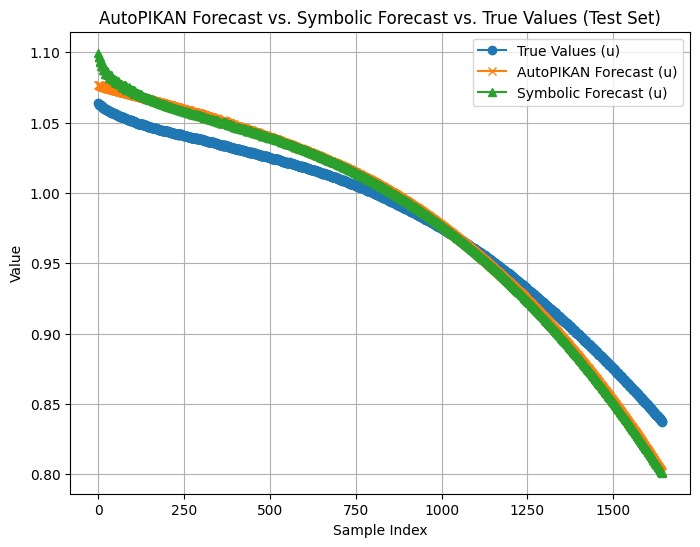

In [57]:
import matplotlib.pyplot as plt

# Set the interval for the samples to plot
interval = 1643

# Create the plot
plt.figure(figsize=(8, 6))

# Plot the KAN forecasts and symbolic forecasts against the true values for id_k1
plt.plot(true_label[:interval], label='True Values (u)', marker='o')
plt.plot(pred_label[:interval], label='AutoPIKAN Forecast (u)', marker='x')
plt.plot(symbolic_forecast1[:interval], label='Symbolic Forecast (u)', marker='^')
# plt.ylim(0.79, 1.01)
# plt.yticks(np.arange(0.80, 1.01, 0.05))

# Customize the plot
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('AutoPIKAN Forecast vs. Symbolic Forecast vs. True Values (Test Set)')
plt.legend()
plt.grid(True)

# Save the plot to a specific location
save_path = '../Images/autopikan_hust_var2/paper_img/reality_vs_autopikan_vs_symbolic_first400.png'  # Change this path as needed
plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
print("image saved at "+save_path)

# Show the plot
plt.show()

image saved at ../Images/autopikan_hust_var2/paper_img/reality_vs_autopikan_vs_symbolic.png


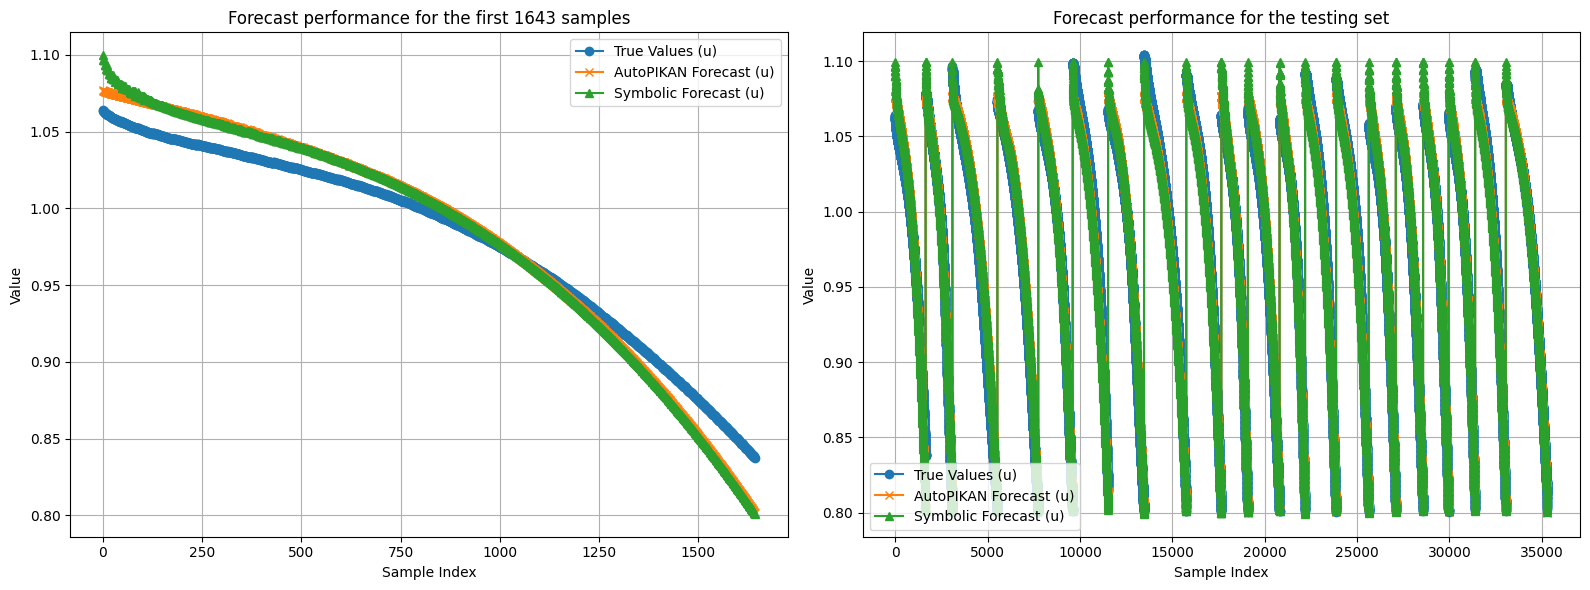

In [58]:
import matplotlib.pyplot as plt

# Set the interval for the first plot (first 50 samples)
interval = 1643

# Create the figure and axes for side-by-side plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot the first interval 
axes[0].plot(true_label[:interval], label='True Values (u)', marker='o')
axes[0].plot(pred_label[:interval], label='AutoPIKAN Forecast (u)', marker='x')
axes[0].plot(symbolic_forecast1[:interval], label='Symbolic Forecast (u)', marker='^')
# axes[0].set(ylim=(0.79, 1.01),yticks=np.arange(0.80, 1.01, 0.05))

# Set the title and labels for the first plot
axes[0].set_title(f'Forecast performance for the first {interval} samples')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Value')
axes[0].legend()
axes[0].grid(True)

# Plot the second interval (entire dataset)
axes[1].plot(true_label, label='True Values (u)', marker='o')
axes[1].plot(pred_label, label='AutoPIKAN Forecast (u)', marker='x')
axes[1].plot(symbolic_forecast1, label='Symbolic Forecast (u)', marker='^')
# axes[1].set(ylim=(0.81, 1.04),yticks=np.arange(0.85, 1.00, 0.05))

# Set the title and labels for the second plot
axes[1].set_title('Forecast performance for the testing set')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].grid(True)

# Save the plot to a specific location
save_path = '../Images/autopikan_hust_var2/paper_img/reality_vs_autopikan_vs_symbolic.png'  # Change this path as needed
plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
print("image saved at "+save_path)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [ ]:
import gc
torch.cuda.empty_cache()
gc.collect()